In [41]:
!pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp311-cp311-win_amd64.whl.metadata (15 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp311-cp311-win_amd64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import platform
from scipy.stats import pearsonr
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [ ]:
# CSV 파일 로드
df = pd.read_csv("merged_data.csv")

# 필요한 컬럼만 사용
df = df[[
    "일시", "자치구", "총생활인구수",
    "지하철_승차총승객수", "버스_승차총승객수"
]]

# 결측치 제거
df = df.dropna(subset=["총생활인구수", "지하철_승차총승객수", "버스_승차총승객수"])

# 날짜와 자치구별로 그룹화하여 합계 계산 (시간대별 데이터 통합)
grouped = df.groupby(["일시", "자치구"]).agg({
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 대중교통 이용객수 합산
grouped["총_대중교통_이용객수"] = (
    grouped["지하철_승차총승객수"] + grouped["버스_승차총승객수"]
)

# 인구수 대비 대중교통 이용비율
grouped["이용비율"] = grouped["총_대중교통_이용객수"] / grouped["총생활인구수"]
grouped["이용비율(%)"] = grouped["이용비율"] * 100

# 결과 확인
print(grouped.head(25))

# CSV로 저장 (선택)
grouped.to_csv("인구대비_대중교통이용비율.csv", index=False)

            일시   자치구        총생활인구수  지하철_승차총승객수  버스_승차총승객수  총_대중교통_이용객수  \
0   2020-01-01   강남구  1.360983e+06      390972     240056       631028   
1   2020-01-01   강동구  1.010090e+06      139378     110630       250008   
2   2020-01-01   강북구  6.493055e+05       83954     217398       301352   
3   2020-01-01   강서구  1.099281e+06      233358     188056       421414   
4   2020-01-01   관악구  1.012750e+06      122674     310096       432770   
5   2020-01-01   광진구  7.628982e+05      164346     120644       284990   
6   2020-01-01   구로구  7.915110e+05      192718     218914       411632   
7   2020-01-01   금천구  4.113434e+05       53958     151806       205764   
8   2020-01-01   노원구  1.098396e+06      188276     171002       359278   
9   2020-01-01   도봉구  5.908787e+05       68450     141180       209630   
10  2020-01-01  동대문구  7.064158e+05       99842     193410       293252   
11  2020-01-01   동작구  8.100739e+05      206160     215998       422158   
12  2020-01-01   마포구  8.944441e+05    

- 2020-01-01
- 2020-01-02
- 2020-01-03
- 2020-01-04
- 2020-01-05
- 2020-01-06
- 2020-01-07
- 2020-01-08
- 2020-01-09
- 2020-01-10
- 2020-01-11
- 2020-01-12
- 2020-01-13
- 2020-01-14
- 2020-01-15
- 2020-01-16
- 2020-01-17
- 2020-01-18
- 2020-01-19
- 2020-01-20
- 2020-01-21
- 2020-01-22
- 2020-01-23
- 2020-01-24
- 2020-01-25
- 2020-01-26
- 2020-01-27
- 2020-01-28
- 2020-01-29
- 2020-01-30
- 2020-01-31
- 2020-02-01
- 2020-02-02
- 2020-02-03
- 2020-02-04
- 2020-02-05
- 2020-02-06
- 2020-02-07
- 2020-02-08
- 2020-02-09
- 2020-02-10
- 2020-02-11
- 2020-02-12
- 2020-02-13
- 2020-02-14
- 2020-02-15
- 2020-02-16
- 2020-02-17
- 2020-02-18
- 2020-02-19
- 2020-02-20
- 2020-02-21
- 2020-02-22
- 2020-02-23
- 2020-02-24
- 2020-02-25
- 2020-02-26
- 2020-02-27
- 2020-02-28
- 2020-02-29
- 2020-03-01
- 2020-03-02
- 2020-03-03
- 2020-03-04
- 2020-03-05
- 2020-03-06
- 2020-03-07
- 2020-03-08
- 2020-03-09
- 2020-03-10
- 2020-03-11
- 2020-03-12
- 2020-03-13
- 2020-03-14
- 2020-03-15
- 2020-03-16
- 2020-03-17

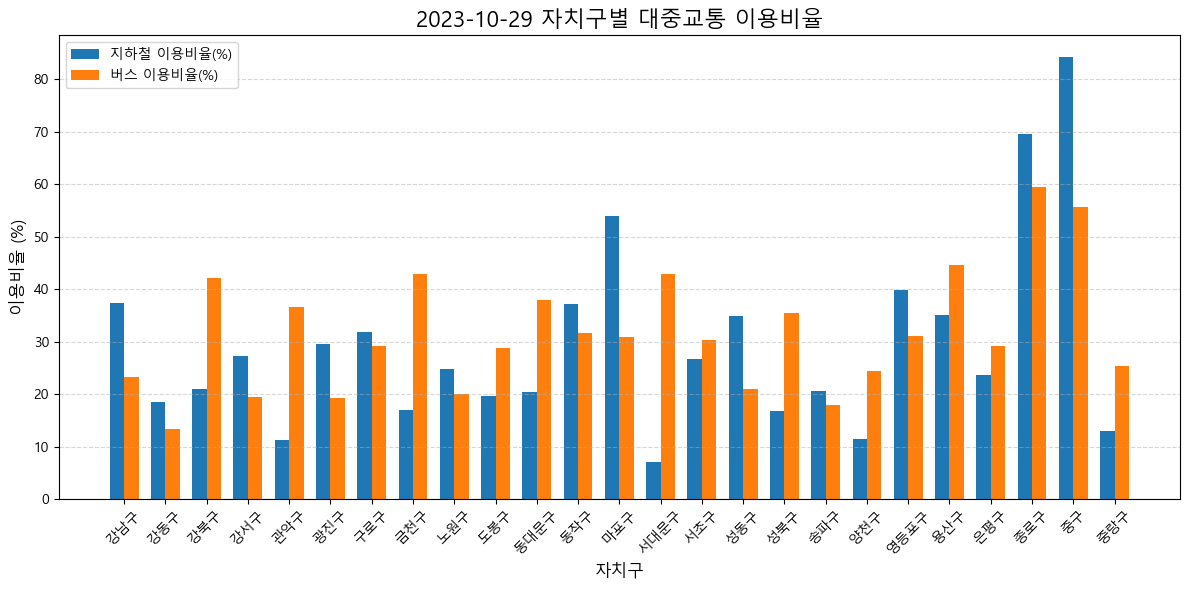

In [14]:
# ✅ 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fontprop = fm.FontProperties(fname=font_path)
    plt.rc('font', family=fontprop.get_name())

plt.rcParams['axes.unicode_minus'] = False

# ✅ 데이터 불러오기
df = pd.read_csv("인구대비_대중교통이용비율.csv")
df["일시"] = pd.to_datetime(df["일시"])
df["일자"] = df["일시"].dt.date

# ✅ 선택 가능한 날짜 출력
available_dates = df["일자"].unique()
# print("📅 선택 가능한 날짜 목록:")
for d in available_dates:
    print(f"- {d}")

# ✅ 사용자로부터 날짜 입력 받기
selected_date = input("\n날짜를 입력하세요 (예: 2025-04-01): ").strip()

# 날짜 형식 검증
try:
    selected_date = pd.to_datetime(selected_date).date()
except:
    print("❌ 날짜 형식이 올바르지 않습니다. 예: 2025-04-01")
    exit()

# ✅ 해당 날짜 데이터 필터링
if selected_date not in available_dates:
    print("❌ 해당 날짜의 데이터가 없습니다.")
else:
    date_df = df[df["일자"] == selected_date].copy()

    # 비율 계산
    date_df["지하철_이용비율(%)"] = (date_df["지하철_승차총승객수"] / date_df["총생활인구수"]) * 100
    date_df["버스_이용비율(%)"] = (date_df["버스_승차총승객수"] / date_df["총생활인구수"]) * 100

    # 그래프 준비
    gu_names = date_df["자치구"].tolist()
    x = np.arange(len(gu_names))
    width = 0.35

    # 그래프 그리기
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, date_df["지하철_이용비율(%)"], width, label="지하철 이용비율(%)")
    ax.bar(x + width/2, date_df["버스_이용비율(%)"], width, label="버스 이용비율(%)")

    # 스타일
    ax.set_title(f"{selected_date} 자치구별 대중교통 이용비율", fontsize=16)
    ax.set_xlabel("자치구", fontsize=12)
    ax.set_ylabel("이용비율 (%)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(gu_names, rotation=45)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


[지하철] 여성비율 vs 이용비율 상관계수: -0.424, p-value: 0.0348
[버스] 여성비율 vs 이용비율 상관계수: -0.256, p-value: 0.2173


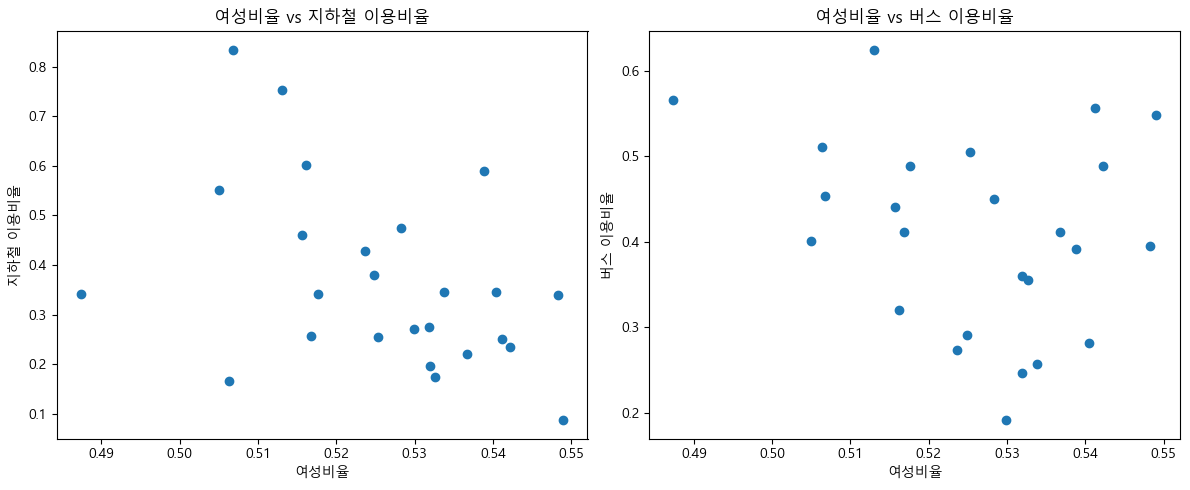

In [17]:
# 데이터 로드
df = pd.read_csv("merged_data.csv")

# 결측치 제거 (필요한 컬럼만)
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "남자미성년자", "남자청년", "남자중년", "남자노년",
    "여자미성년자", "여자청년", "여자중년", "여자노년"
])

# 자치구별로 그룹화하여 성별 인구 합산 및 교통 이용 합계
grouped = df.groupby("자치구").agg({
    "남자미성년자": "sum", "남자청년": "sum", "남자중년": "sum", "남자노년": "sum",
    "여자미성년자": "sum", "여자청년": "sum", "여자중년": "sum", "여자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 남성 / 여성 인구 합산
grouped["남성인구"] = grouped["남자미성년자"] + grouped["남자청년"] + grouped["남자중년"] + grouped["남자노년"]
grouped["여성인구"] = grouped["여자미성년자"] + grouped["여자청년"] + grouped["여자중년"] + grouped["여자노년"]

# 여성 비율 계산
grouped["여성비율"] = grouped["여성인구"] / (grouped["남성인구"] + grouped["여성인구"])

# 교통 이용 비율
grouped["지하철_이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스_이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 상관관계 분석
corr_subway, p_subway = pearsonr(grouped["여성비율"], grouped["지하철_이용비율"])
corr_bus, p_bus = pearsonr(grouped["여성비율"], grouped["버스_이용비율"])

print(f"[지하철] 여성비율 vs 이용비율 상관계수: {corr_subway:.3f}, p-value: {p_subway:.4f}")
print(f"[버스] 여성비율 vs 이용비율 상관계수: {corr_bus:.3f}, p-value: {p_bus:.4f}")

# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(grouped["여성비율"], grouped["지하철_이용비율"])
plt.title("여성비율 vs 지하철 이용비율")
plt.xlabel("여성비율")
plt.ylabel("지하철 이용비율")

plt.subplot(1, 2, 2)
plt.scatter(grouped["여성비율"], grouped["버스_이용비율"])
plt.title("여성비율 vs 버스 이용비율")
plt.xlabel("여성비율")
plt.ylabel("버스 이용비율")

plt.tight_layout()
plt.show()

In [ ]:
# ✔ 지하철 이용비율 vs 여성비율
# 상관계수가 -0.424: 여성비율이 높은 자치구일수록 지하철 이용비율이 다소 낮은 경향이 있다는 의미예요.

# p-value가 0.0348 (< 0.05): 이 결과는 통계적으로 유의미합니다.
# 👉 즉, 단순한 우연이 아니라 실제로 어느 정도의 패턴이 있는 것으로 볼 수 있어요.

# ❌ 버스 이용비율 vs 여성비율
# 상관계수가 -0.256: 버스에 대해서도 비슷하게 여성 비율이 높을수록 이용률이 약간 낮은 경향이 있지만

# p-value가 0.2173: 이건 유의미하지 않음 → 우연일 가능성이 높아요.

In [18]:
# 데이터 불러오기
df = pd.read_csv("merged_data.csv")

# 결측치 제거
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "여자미성년자", "여자청년", "여자중년", "여자노년"
])

# 자치구별 집계
grouped = df.groupby("자치구").agg({
    "여자미성년자": "sum",
    "여자청년": "sum",
    "여자중년": "sum",
    "여자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 전체 여성 인구 합
grouped["여성합계"] = (
    grouped["여자미성년자"] + grouped["여자청년"] +
    grouped["여자중년"] + grouped["여자노년"]
)

# 각 연령대의 여성 비율
grouped["미성년비율"] = grouped["여자미성년자"] / grouped["여성합계"]
grouped["청년비율"]   = grouped["여자청년"] / grouped["여성합계"]
grouped["중년비율"]   = grouped["여자중년"] / grouped["여성합계"]
grouped["노년비율"]   = grouped["여자노년"] / grouped["여성합계"]

# 교통 이용 비율
grouped["지하철_이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스_이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 상관관계 분석
def analyze_correlation(age_group_col, transport_col):
    r, p = pearsonr(grouped[age_group_col], grouped[transport_col])
    return r, p

for age_col in ["미성년비율", "청년비율", "중년비율", "노년비율"]:
    r_sub, p_sub = analyze_correlation(age_col, "지하철_이용비율")
    r_bus, p_bus = analyze_correlation(age_col, "버스_이용비율")
    print(f"[{age_col}] vs 지하철: r={r_sub:.3f}, p={p_sub:.4f}")
    print(f"[{age_col}] vs 버스: r={r_bus:.3f}, p={p_bus:.4f}")
    print("-" * 50)
    

[미성년비율] vs 지하철: r=-0.523, p=0.0073
[미성년비율] vs 버스: r=-0.545, p=0.0049
--------------------------------------------------
[청년비율] vs 지하철: r=0.476, p=0.0162
[청년비율] vs 버스: r=0.269, p=0.1937
--------------------------------------------------
[중년비율] vs 지하철: r=0.084, p=0.6902
[중년비율] vs 버스: r=-0.164, p=0.4345
--------------------------------------------------
[노년비율] vs 지하철: r=-0.469, p=0.0181
[노년비율] vs 버스: r=0.137, p=0.5135
--------------------------------------------------


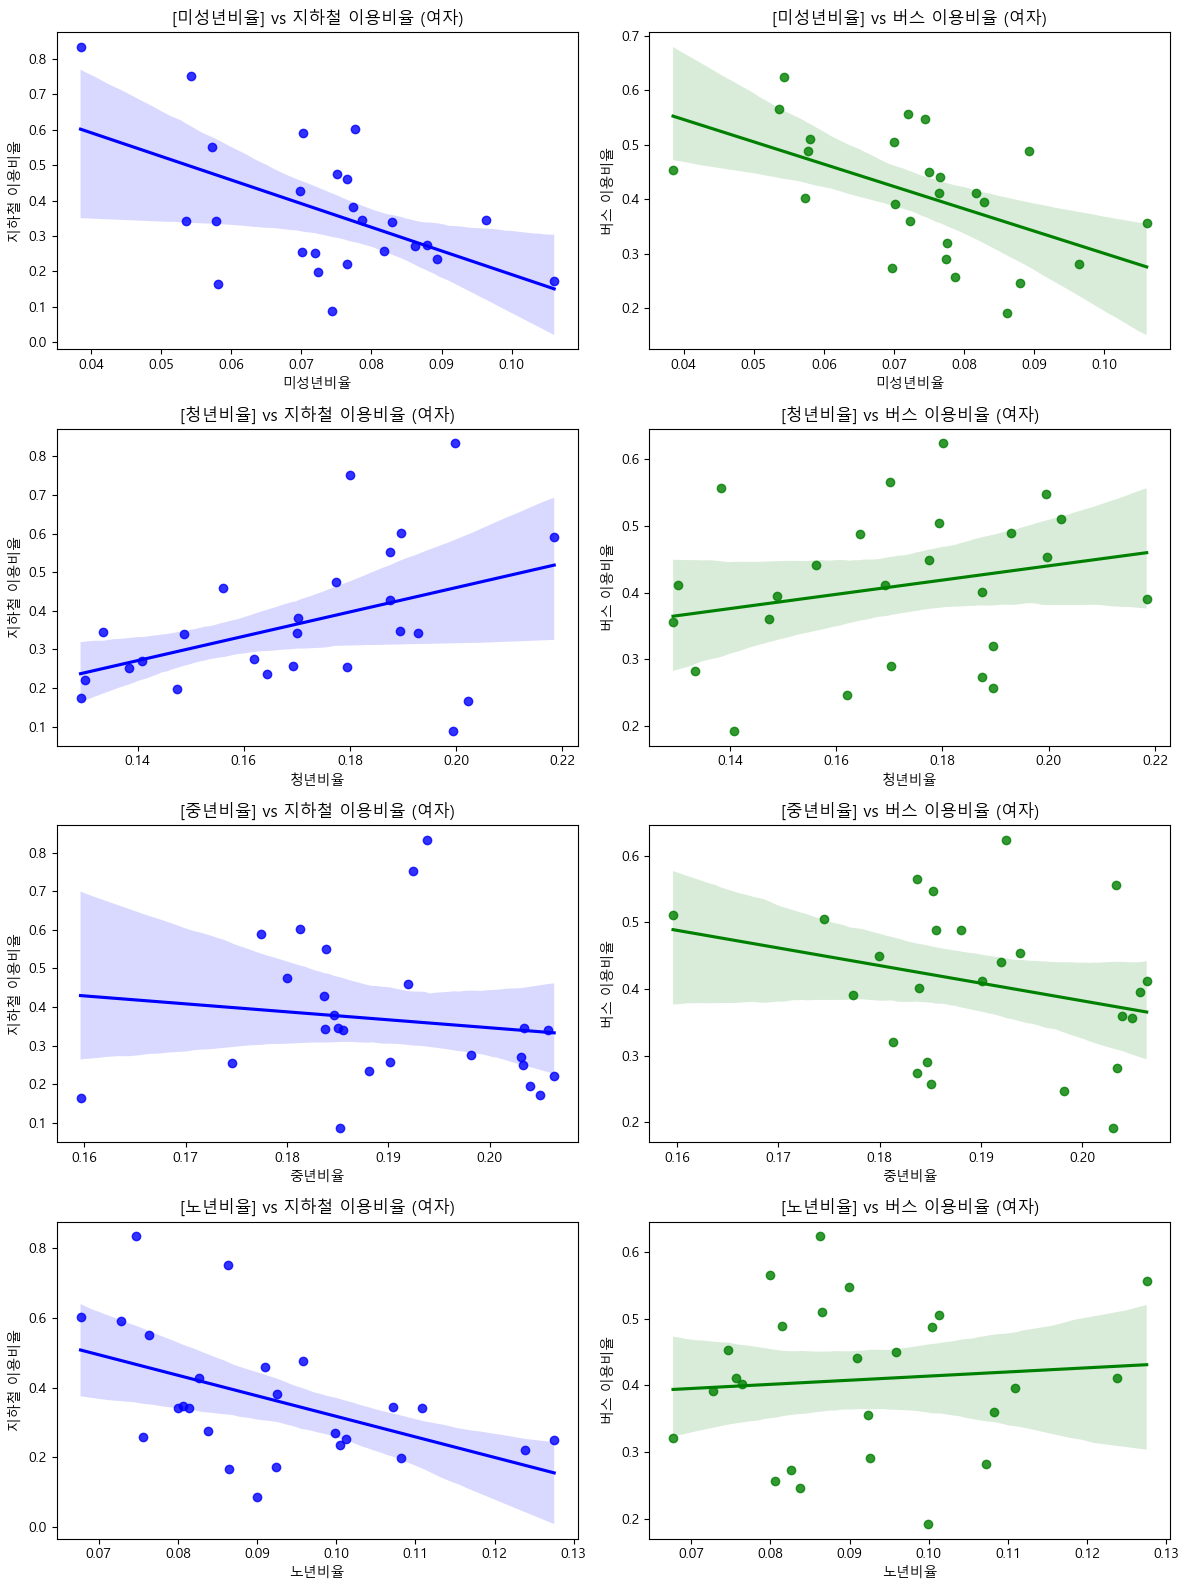

In [46]:
# 폰트 설정 (한글 깨짐 방지)
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows인 경우
# plt.rcParams["font.family"] = "AppleGothic"  # macOS인 경우
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드 및 전처리
df = pd.read_csv("merged_data.csv")  # 실제 경로 반영
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "여자미성년자", "여자청년", "여자중년", "여자노년"
])

# 자치구별 집계
grouped = df.groupby("자치구").agg({
    "여자미성년자": "sum", "여자청년": "sum", "여자중년": "sum", "여자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 연령대 비율 계산
grouped["미성년비율"] = grouped["여자미성년자"] / grouped["총생활인구수"]
grouped["청년비율"] = grouped["여자청년"] / grouped["총생활인구수"]
grouped["중년비율"] = grouped["여자중년"] / grouped["총생활인구수"]
grouped["노년비율"] = grouped["여자노년"] / grouped["총생활인구수"]

# 교통 이용 비율 계산
grouped["지하철이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 시각화
age_groups = ["미성년비율", "청년비율", "중년비율", "노년비율"]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for i, age in enumerate(age_groups):
    sns.regplot(
        x=grouped[age], y=grouped["지하철이용비율"],
        ax=axes[i, 0], color="blue"
    )
    axes[i, 0].set_title(f"[{age}] vs 지하철 이용비율 (여자)")
    axes[i, 0].set_xlabel(age)
    axes[i, 0].set_ylabel("지하철 이용비율")

    sns.regplot(
        x=grouped[age], y=grouped["버스이용비율"],
        ax=axes[i, 1], color="green"
    )
    axes[i, 1].set_title(f"[{age}] vs 버스 이용비율 (여자)")
    axes[i, 1].set_xlabel(age)
    axes[i, 1].set_ylabel("버스 이용비율")

plt.tight_layout()
plt.show()

In [ ]:
# ✅ 미성년 여성 인구 비율이 높을수록 대중교통 이용이 낮다
# 집 근처 학교 중심 생활 → 대중교통 이용 적음

# 보호자 동반/도보 이동의 가능성

# ✅ 청년 여성 인구 비율이 높을수록 지하철 이용이 많다
# 통학/출퇴근 등으로 지하철 선호

# 특히 수도권 중심 대학/직장이 밀집된 자치구일 가능성

# ✅ 노년층 여성 비율이 높을수록 지하철 이용이 낮다
# 대중교통 접근성/이용 피로감/도보 이동 제약 등 가능성

[지하철] 남성비율 vs 이용비율 상관계수: 0.424, p-value: 0.0348
[버스] 남성비율 vs 이용비율 상관계수: 0.256, p-value: 0.2173


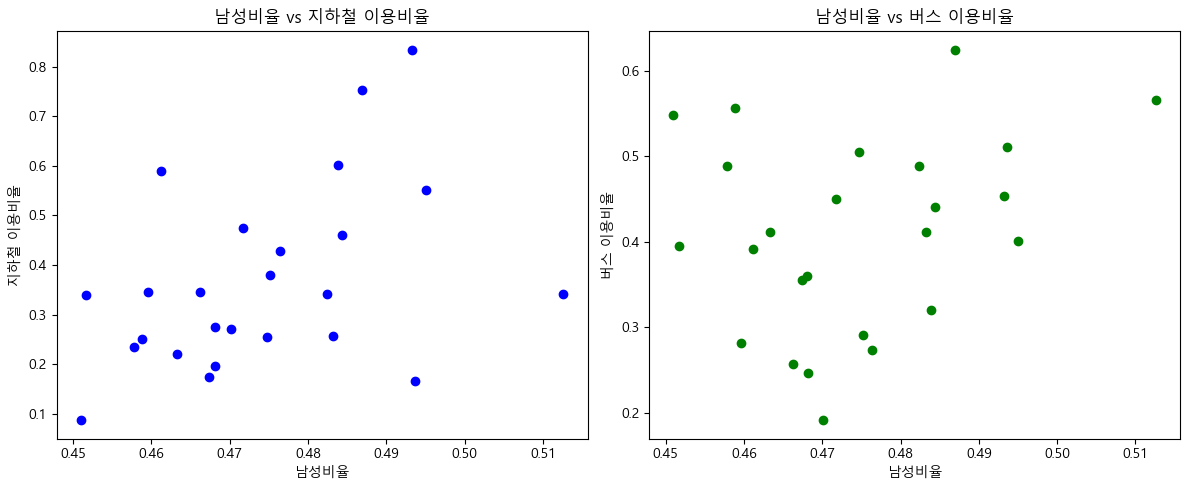

In [29]:
df = pd.read_csv("merged_data.csv")

# 결측치 제거 (필요한 컬럼만)
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "남자미성년자", "남자청년", "남자중년", "남자노년",
    "여자미성년자", "여자청년", "여자중년", "여자노년"
])

# 자치구별로 그룹화하여 성별 인구 합산 및 교통 이용 합계
grouped = df.groupby("자치구").agg({
    "남자미성년자": "sum", "남자청년": "sum", "남자중년": "sum", "남자노년": "sum",
    "여자미성년자": "sum", "여자청년": "sum", "여자중년": "sum", "여자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 남성 / 여성 인구 합산
grouped["남성인구"] = grouped["남자미성년자"] + grouped["남자청년"] + grouped["남자중년"] + grouped["남자노년"]
grouped["여성인구"] = grouped["여자미성년자"] + grouped["여자청년"] + grouped["여자중년"] + grouped["여자노년"]

# 남성 비율 계산 (전체 대비 남성)
grouped["남성비율"] = grouped["남성인구"] / (grouped["남성인구"] + grouped["여성인구"])

# 교통 이용 비율
grouped["지하철_이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스_이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 남성비율 vs 지하철/버스 이용비율 상관관계 분석
corr_subway_male, p_subway_male = pearsonr(grouped["남성비율"], grouped["지하철_이용비율"])
corr_bus_male, p_bus_male = pearsonr(grouped["남성비율"], grouped["버스_이용비율"])

print(f"[지하철] 남성비율 vs 이용비율 상관계수: {corr_subway_male:.3f}, p-value: {p_subway_male:.4f}")
print(f"[버스] 남성비율 vs 이용비율 상관계수: {corr_bus_male:.3f}, p-value: {p_bus_male:.4f}")

# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(grouped["남성비율"], grouped["지하철_이용비율"], color="blue")
plt.title("남성비율 vs 지하철 이용비율")
plt.xlabel("남성비율")
plt.ylabel("지하철 이용비율")

plt.subplot(1, 2, 2)
plt.scatter(grouped["남성비율"], grouped["버스_이용비율"], color="green")
plt.title("남성비율 vs 버스 이용비율")
plt.xlabel("남성비율")
plt.ylabel("버스 이용비율")

plt.tight_layout()
plt.show()


In [30]:
# 🟦 지하철
# 상관계수(r) = 0.424: 양의 상관관계, 즉 남성 비율이 높을수록 지하철 이용률도 높아지는 경향이 있음.

# p-value = 0.0348: 유의수준 0.05보다 작으므로, 통계적으로 유의미함.

# → 남성 비율이 높은 자치구는 실제로 지하철을 더 많이 이용할 가능성이 있음.

# 🟩 버스
# 상관계수(r) = 0.256: 약한 양의 상관관계. 남성 비율이 높을수록 버스 이용이 약간 증가할 수는 있지만,

# p-value = 0.2173: 유의수준보다 크므로 통계적으로 유의하지 않음.

# → 우연일 가능성이 있으며, 확실한 결론을 내리기 어려움.

In [31]:
# 데이터 로드 및 결측치 제거
df = pd.read_csv("merged_data.csv")
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "남자미성년자", "남자청년", "남자중년", "남자노년"
])

# 자치구별로 그룹화하여 인구 및 교통량 합계
grouped = df.groupby("자치구").agg({
    "남자미성년자": "sum", "남자청년": "sum", "남자중년": "sum", "남자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 남성 전체 인구수
grouped["남성인구"] = grouped[["남자미성년자", "남자청년", "남자중년", "남자노년"]].sum(axis=1)

# 연령대별 비율
grouped["미성년비율"] = grouped["남자미성년자"] / grouped["남성인구"]
grouped["청년비율"]   = grouped["남자청년"] / grouped["남성인구"]
grouped["중년비율"]   = grouped["남자중년"] / grouped["남성인구"]
grouped["노년비율"]   = grouped["남자노년"] / grouped["남성인구"]

# 교통 이용 비율
grouped["지하철_이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스_이용비율"]   = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 분석 대상
연령대 = ["미성년", "청년", "중년", "노년"]

# 결과 출력
print("남성 연령대별 비율 vs 교통 이용비율 상관관계")
print("-" * 50)
for age in 연령대:
    r_subway, p_subway = pearsonr(grouped[f"{age}비율"], grouped["지하철_이용비율"])
    r_bus, p_bus = pearsonr(grouped[f"{age}비율"], grouped["버스_이용비율"])
    print(f"[{age}비율] vs 지하철: r={r_subway:.3f}, p={p_subway:.4f}")
    print(f"[{age}비율] vs 버스: r={r_bus:.3f}, p={p_bus:.4f}")
    print("-" * 50)


남성 연령대별 비율 vs 교통 이용비율 상관관계
--------------------------------------------------
[미성년비율] vs 지하철: r=-0.529, p=0.0065
[미성년비율] vs 버스: r=-0.543, p=0.0051
--------------------------------------------------
[청년비율] vs 지하철: r=0.294, p=0.1533
[청년비율] vs 버스: r=0.305, p=0.1375
--------------------------------------------------
[중년비율] vs 지하철: r=0.567, p=0.0031
[중년비율] vs 버스: r=0.190, p=0.3643
--------------------------------------------------
[노년비율] vs 지하철: r=-0.339, p=0.0975
[노년비율] vs 버스: r=0.156, p=0.4560
--------------------------------------------------


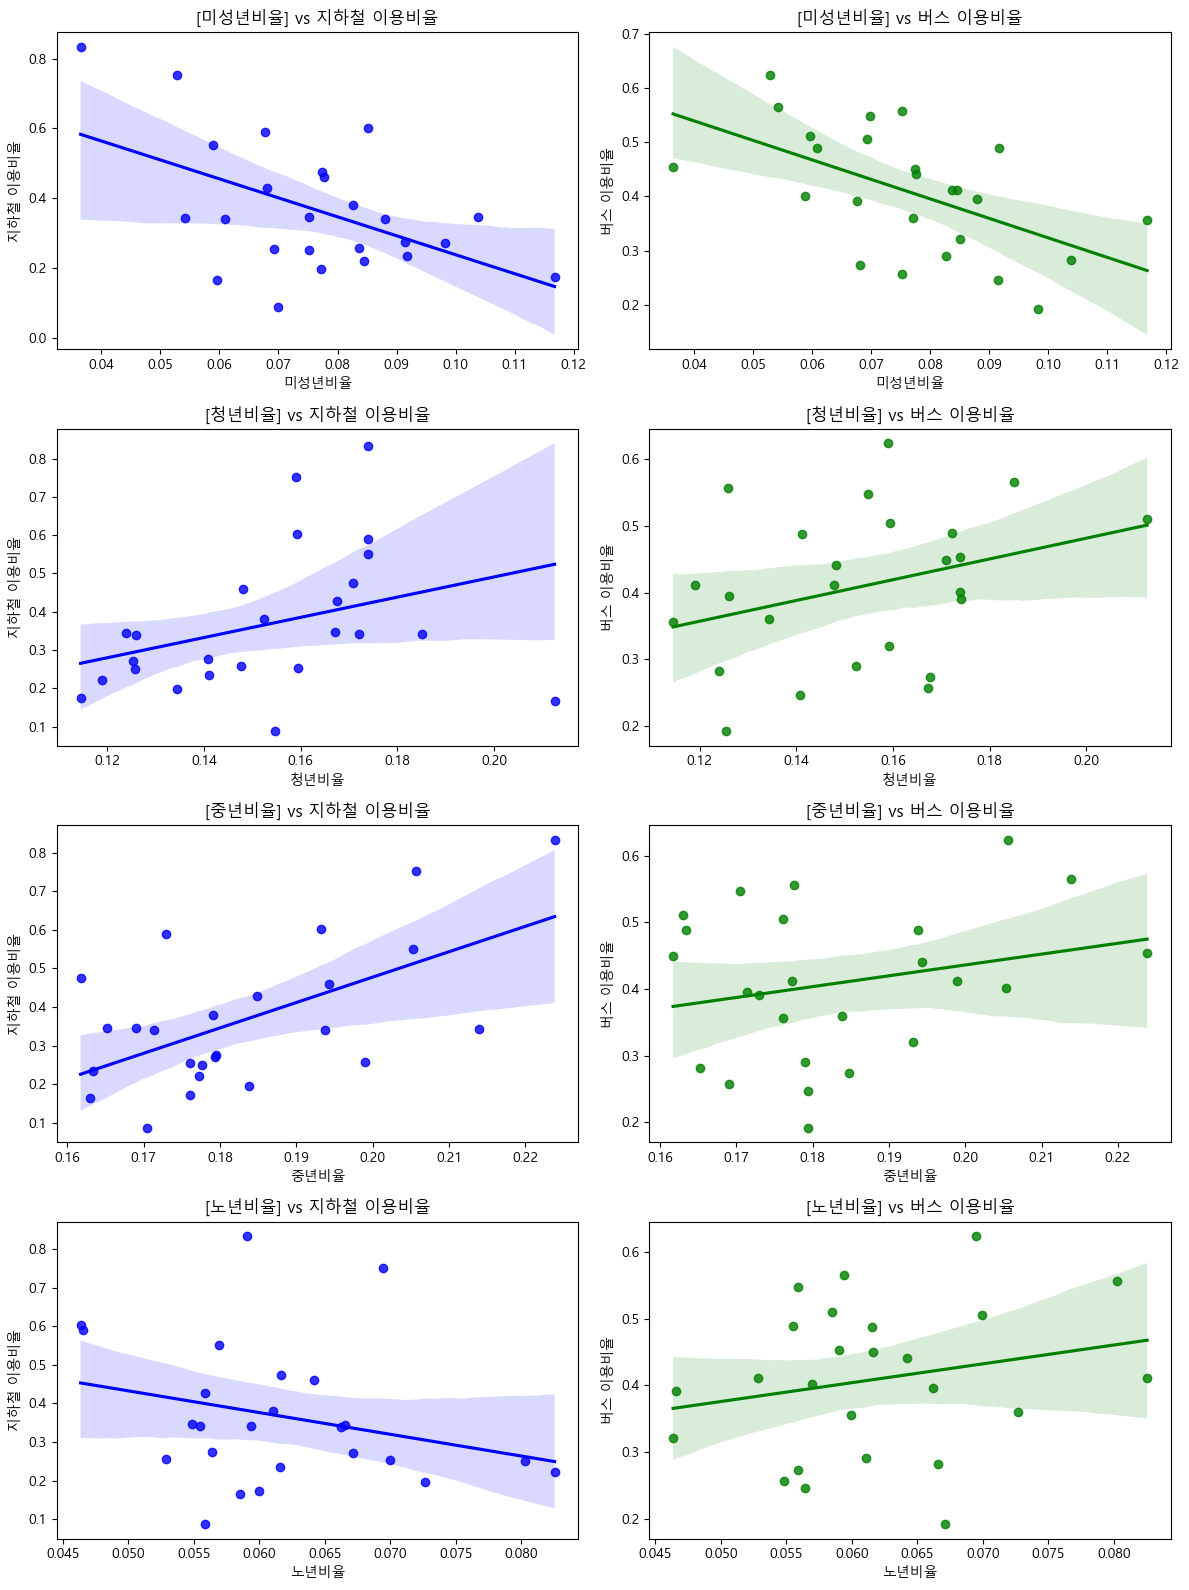

In [33]:
# 폰트 설정 (한글 깨짐 방지)
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows인 경우
# plt.rcParams["font.family"] = "AppleGothic"  # macOS인 경우
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드 및 전처리
df = pd.read_csv("merged_data.csv")
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "남자미성년자", "남자청년", "남자중년", "남자노년"
])

# 자치구별 집계
grouped = df.groupby("자치구").agg({
    "남자미성년자": "sum", "남자청년": "sum", "남자중년": "sum", "남자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 연령대 비율
grouped["미성년비율"] = grouped["남자미성년자"] / grouped["총생활인구수"]
grouped["청년비율"] = grouped["남자청년"] / grouped["총생활인구수"]
grouped["중년비율"] = grouped["남자중년"] / grouped["총생활인구수"]
grouped["노년비율"] = grouped["남자노년"] / grouped["총생활인구수"]

# 교통 이용 비율
grouped["지하철이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 시각화
age_groups = ["미성년비율", "청년비율", "중년비율", "노년비율"]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for i, age in enumerate(age_groups):
    sns.regplot(
        x=grouped[age], y=grouped["지하철이용비율"],
        ax=axes[i, 0], color="blue"
    )
    axes[i, 0].set_title(f"[{age}] vs 지하철 이용비율")
    axes[i, 0].set_xlabel(age)
    axes[i, 0].set_ylabel("지하철 이용비율")

    sns.regplot(
        x=grouped[age], y=grouped["버스이용비율"],
        ax=axes[i, 1], color="green"
    )
    axes[i, 1].set_title(f"[{age}] vs 버스 이용비율")
    axes[i, 1].set_xlabel(age)
    axes[i, 1].set_ylabel("버스 이용비율")

plt.tight_layout()
plt.show()

In [ ]:
# 해석
# 미성년 남성이 많은 자치구는 지하철·버스 모두 이용 비율이 낮음

# 중년 남성이 많은 자치구는 지하철 이용 비율이 높음

# 청년·노년층은 유의미한 상관이 없거나 약함

# 이 결과는 출퇴근 중심의 지하철 이용 패턴이 중년 남성의 높은 활동성과 일치하고,
# 미성년층은 보호자와 함께 이동하거나 교통수단을 자주 사용하지 않기 때문일 수 있습니다.

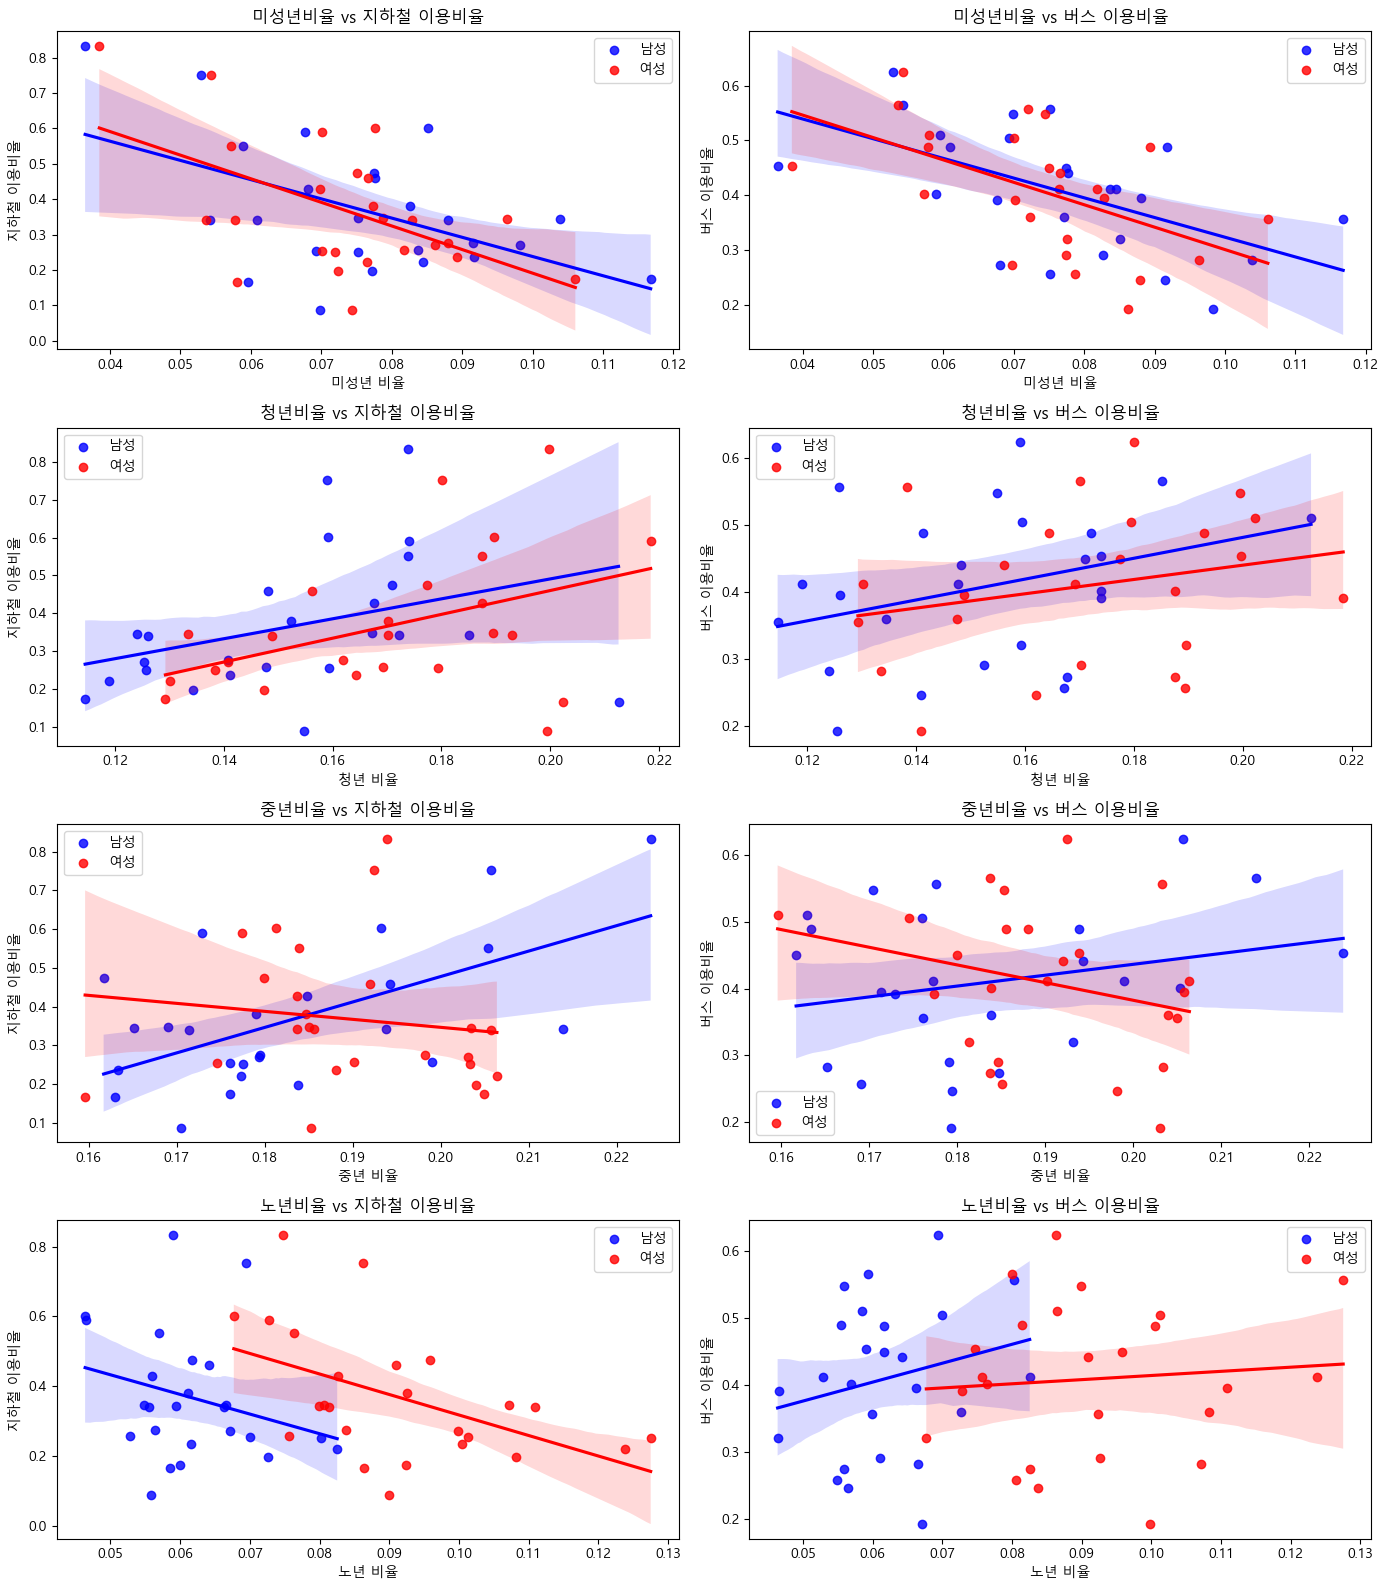

In [34]:
# 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows
# plt.rcParams["font.family"] = "AppleGothic"  # macOS
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드 및 전처리
df = pd.read_csv("merged_data.csv")
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "남자미성년자", "남자청년", "남자중년", "남자노년",
    "여자미성년자", "여자청년", "여자중년", "여자노년"
])

# 자치구별 집계
grouped = df.groupby("자치구").agg({
    "남자미성년자": "sum", "남자청년": "sum", "남자중년": "sum", "남자노년": "sum",
    "여자미성년자": "sum", "여자청년": "sum", "여자중년": "sum", "여자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 비율 계산
grouped["남_미성년비율"] = grouped["남자미성년자"] / grouped["총생활인구수"]
grouped["남_청년비율"] = grouped["남자청년"] / grouped["총생활인구수"]
grouped["남_중년비율"] = grouped["남자중년"] / grouped["총생활인구수"]
grouped["남_노년비율"] = grouped["남자노년"] / grouped["총생활인구수"]

grouped["여_미성년비율"] = grouped["여자미성년자"] / grouped["총생활인구수"]
grouped["여_청년비율"] = grouped["여자청년"] / grouped["총생활인구수"]
grouped["여_중년비율"] = grouped["여자중년"] / grouped["총생활인구수"]
grouped["여_노년비율"] = grouped["여자노년"] / grouped["총생활인구수"]

# 교통 이용 비율
grouped["지하철이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 시각화
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
age_labels = ["미성년", "청년", "중년", "노년"]

for i, label in enumerate(age_labels):
    # 지하철
    sns.regplot(
        x=grouped[f"남_{label}비율"],
        y=grouped["지하철이용비율"],
        ax=axes[i, 0],
        label="남성", color="blue"
    )
    sns.regplot(
        x=grouped[f"여_{label}비율"],
        y=grouped["지하철이용비율"],
        ax=axes[i, 0],
        label="여성", color="red"
    )
    axes[i, 0].set_title(f"{label}비율 vs 지하철 이용비율")
    axes[i, 0].set_xlabel(f"{label} 비율")
    axes[i, 0].set_ylabel("지하철 이용비율")
    axes[i, 0].legend()

    # 버스
    sns.regplot(
        x=grouped[f"남_{label}비율"],
        y=grouped["버스이용비율"],
        ax=axes[i, 1],
        label="남성", color="blue"
    )
    sns.regplot(
        x=grouped[f"여_{label}비율"],
        y=grouped["버스이용비율"],
        ax=axes[i, 1],
        label="여성", color="red"
    )
    axes[i, 1].set_title(f"{label}비율 vs 버스 이용비율")
    axes[i, 1].set_xlabel(f"{label} 비율")
    axes[i, 1].set_ylabel("버스 이용비율")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

In [43]:
# 데이터 로드 및 전처리
df = pd.read_csv("merged_data.csv")
df = df.dropna(subset=[
    "총생활인구수", "지하철_승차총승객수", "버스_승차총승객수",
    "남자미성년자", "남자청년", "남자중년", "남자노년",
    "여자미성년자", "여자청년", "여자중년", "여자노년"
])

# 자치구별 집계
grouped = df.groupby("자치구").agg({
    "남자미성년자": "sum", "남자청년": "sum", "남자중년": "sum", "남자노년": "sum",
    "여자미성년자": "sum", "여자청년": "sum", "여자중년": "sum", "여자노년": "sum",
    "총생활인구수": "sum",
    "지하철_승차총승객수": "sum",
    "버스_승차총승객수": "sum"
}).reset_index()

# 연령대별 비율 계산
for gender in ['남자', '여자']:
    for age in ['미성년자', '청년', '중년', '노년']:
        col = f"{gender}{age}"
        grouped[f"{col}_비율"] = grouped[col] / grouped["총생활인구수"]

# 종속변수 (지하철 이용비율 또는 버스 이용비율)
grouped["지하철이용비율"] = grouped["지하철_승차총승객수"] / grouped["총생활인구수"]
grouped["버스이용비율"] = grouped["버스_승차총승객수"] / grouped["총생활인구수"]

# 입력 변수(X), 출력 변수(y)
X = grouped[[col for col in grouped.columns if "_비율" in col]]
y = grouped["지하철이용비율"]  # ← 또는 "버스이용비율" 로 바꿔서 버스 예측 가능

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 결과 출력
print("다중회귀 예측 결과")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.5f}")
print("회귀 계수:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.5f}")

다중회귀 예측 결과
R² Score: 0.142
RMSE: 0.19267
회귀 계수:
남자미성년자_비율: 63593524.59944
남자청년_비율: 63593520.95017
남자중년_비율: 63593524.72007
남자노년_비율: 63593540.49837
여자미성년자_비율: 63593518.74171
여자청년_비율: 63593528.55426
여자중년_비율: 63593529.97558
여자노년_비율: 63593512.02813
